# Machine Learning Lab Projekt
# Group 2
# Topic : Student Depression

Link to our Dataset on kaggle: https://www.kaggle.com/datasets/adilshamim8/student-depression-dataset/data

---

## Imports

(section for the necessary Imports)

In [43]:
import pandas as pd  # for data analysis
import numpy as np # for numerical computations
import matplotlib.pyplot as plt # for creating plots


from sklearn.ensemble import RandomForestClassifier # for creating random forest
from sklearn.model_selection import train_test_split # for train-test-splitting the data
from sklearn.tree import DecisionTreeClassifier # for creating decision trees
from sklearn import tree # required to plot decision trees
from sklearn.metrics import accuracy_score # for calculating accuracy
from sklearn.metrics import confusion_matrix # for calculating sensitivity and specificity
from sklearn.model_selection import GridSearchCV # for tuning hyperparameters
from sklearn.preprocessing import MinMaxScaler # for normalizing columns
from sklearn.metrics import ConfusionMatrixDisplay # for plotting confusion matrices

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

## Introduction + Overview of Columns

This dataset contains comprehensive information about students’ mental health and related factors. It is designed to analyze the trends and predictors of depression among students. The data includes demographic details, academic and work-related pressures, lifestyle habits, and specific mental health indicators. This dataset can be used to identify risk factors for depression and develop strategies for early intervention, while ensuring ethical handling of sensitive information. 
The aim of our project is to use machine learning models to predict whether someone has depression or not based on various factors from the columns. We have the opportunity to test various models from the lecture on real data and evaluate which ones work well. for example, we can use decision trees to examine which factors the model focused on most in order to classify people as having depression or not.



<b>Field Descriptions</b>

<b>id</b>
A unique identifier assigned to each student record in the dataset.

<b>Gender</b>
The gender of the student (e.g., Male, Female, Other). This helps in analyzing gender-specific trends in mental health.

<b>Age</b>
The age of the student in years.

<b>City</b>
The city or region where the student resides, providing geographical context for the analysis.

<b>Profession</b>
The field of work or study of the student, which may offer insights into occupational or academic stress factors.

<b>Academic Pressure</b>
A measure indicating the level of pressure the student faces in academic settings. This could include stress from exams, assignments, and overall academic expectations.

<b>Work Pressure</b>
A measure of the pressure related to work or job responsibilities, relevant for students who are employed alongside their studies.

<b>CGPA</b>
The cumulative grade point average of the student, reflecting overall academic performance.

<b>Study Satisfaction</b>
An indicator of how satisfied the student is with their studies, which can correlate with mental well-being.

<b>Job Satisfaction</b>
A measure of the student’s satisfaction with their job or work environment, if applicable.

<b>Sleep Duration</b>
The average number of hours the student sleeps per day, which is an important factor in mental health.

<b>Dietary Habits</b>
An assessment of the student’s eating patterns and nutritional habits, potentially impacting overall health and mood.

<b>Degree</b>
The academic degree or program that the student is pursuing.

<b>Have you ever had suicidal thoughts ?</b>
A binary indicator (Yes/No) that reflects whether the student has ever experienced suicidal ideation.

<b>Work/Study Hours</b>
The average number of hours per day the student dedicates to work or study, which can influence stress levels.

<b>Financial Stress</b>
A measure of the stress experienced due to financial concerns, which may affect mental health.

<b>Family History of Mental Illness</b>
Indicates whether there is a family history of mental illness (Yes/No), which can be a significant factor in mental health predispositions.

<b>Depression</b>
The target variable that indicates whether the student is experiencing depression (Yes/No). This is the primary focus of the analysis.


## Data Understanding + Data Preparation

<b>Step 1:</b> Import Dataset + print first 10 rows

In [56]:
#imports dataset + saves it in variable "df":
df = pd.read_csv('./student_depression_dataset.csv')
#displays the first 10 rows:
df.head(10)

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0
5,33,Male,29.0,Pune,Student,2.0,0.0,5.70,3.0,0.0,'Less than 5 hours',Healthy,PhD,No,4.0,1.0,No,0
6,52,Male,30.0,Thane,Student,3.0,0.0,9.54,4.0,0.0,'7-8 hours',Healthy,BSc,No,1.0,2.0,No,0
7,56,Female,30.0,Chennai,Student,2.0,0.0,8.04,4.0,0.0,'Less than 5 hours',Unhealthy,'Class 12',No,0.0,1.0,Yes,0
8,59,Male,28.0,Nagpur,Student,3.0,0.0,9.79,1.0,0.0,'7-8 hours',Moderate,B.Ed,Yes,12.0,3.0,No,1
9,62,Male,31.0,Nashik,Student,2.0,0.0,8.38,3.0,0.0,'Less than 5 hours',Moderate,LLB,Yes,2.0,5.0,No,1


<b>Step 2:</b> Show simple statistics including min/max values

In [57]:
#shows statistics for all the columns
df.describe(include = 'all')

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
count,27901.000000,27901,27901.000000,27901,27901,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901,27901,27901,27901,27901.000000,27901,27901,27901.000000
unique,NaN,2,NaN,52,14,NaN,NaN,NaN,NaN,NaN,5,4,28,2,NaN,6,2,NaN
top,NaN,Male,NaN,Kalyan,Student,NaN,NaN,NaN,NaN,NaN,'Less than 5 hours',Unhealthy,'Class 12',Yes,NaN,5.0,No,NaN
freq,NaN,15547,NaN,1570,27870,NaN,NaN,NaN,NaN,NaN,8310,10317,6080,17656,NaN,6715,14398,NaN
mean,70442.149421,NaN,25.822300,NaN,NaN,3.141214,0.000430,7.656104,2.943837,0.000681,NaN,NaN,NaN,NaN,7.156984,NaN,NaN,0.585499
std,40641.175216,NaN,4.905687,NaN,NaN,1.381465,0.043992,1.470707,1.361148,0.044394,NaN,NaN,NaN,NaN,3.707642,NaN,NaN,0.492645
min,2.000000,NaN,18.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000
25%,35039.000000,NaN,21.000000,NaN,NaN,2.000000,0.000000,6.290000,2.000000,0.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,0.000000
50%,70684.000000,NaN,25.000000,NaN,NaN,3.000000,0.000000,7.770000,3.000000,0.000000,NaN,NaN,NaN,NaN,8.000000,NaN,NaN,1.000000
75%,105818.000000,NaN,30.000000,NaN,NaN,4.000000,0.000000,8.920000,4.000000,0.000000,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,1.000000


<b>Step 3:</b> Check for missing values:

In [58]:
print("Missing Values per Column:")
print(df.isnull().sum())

Missing Values per Column:
id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64


--> There are no missing values in any of the columns

<b>Step 4:</b> Remove any Columns that we don't need for our Machine Learning Model

Check if there's any columns with only 1 unique value (we want to drop these as they won't have any effect in our predictions) :

In [59]:
print("\nCount of unique Values per Column:")
print(df.nunique())


Count of unique Values per Column:
id                                       27901
Gender                                       2
Age                                         34
City                                        52
Profession                                  14
Academic Pressure                            6
Work Pressure                                3
CGPA                                       332
Study Satisfaction                           6
Job Satisfaction                             5
Sleep Duration                               5
Dietary Habits                               4
Degree                                      28
Have you ever had suicidal thoughts ?        2
Work/Study Hours                            13
Financial Stress                             6
Family History of Mental Illness             2
Depression                                   2
dtype: int64


--> All columns have 2 or more unique values

<p style="color:red">Problem: For some columns, it still seems like all the rows have the same value (e.g. "Occupation" seems to be "Student" for basically every row)</p>

-> For each Column, we are going to print out in how many rows (+ how much % of rows) the value with the highest value count appears:

In [60]:
#loop that iterates through all the columns
for col in df.columns:
    #for each column, prints how often the value with the highest value count occurs
    print(col, 
          ":", 
          df[col].value_counts().max(), 
          "-->", 
          f"The same value appears in {(df[col].value_counts().max() / len(df))*100:.2f}% of the rows")

id : 1 --> The same value appears in 0.00% of the rows
Gender : 15547 --> The same value appears in 55.72% of the rows
Age : 2258 --> The same value appears in 8.09% of the rows
City : 1570 --> The same value appears in 5.63% of the rows
Profession : 27870 --> The same value appears in 99.89% of the rows
Academic Pressure : 7462 --> The same value appears in 26.74% of the rows
Work Pressure : 27898 --> The same value appears in 99.99% of the rows
CGPA : 821 --> The same value appears in 2.94% of the rows
Study Satisfaction : 6359 --> The same value appears in 22.79% of the rows
Job Satisfaction : 27893 --> The same value appears in 99.97% of the rows
Sleep Duration : 8310 --> The same value appears in 29.78% of the rows
Dietary Habits : 10317 --> The same value appears in 36.98% of the rows
Degree : 6080 --> The same value appears in 21.79% of the rows
Have you ever had suicidal thoughts ? : 17656 --> The same value appears in 63.28% of the rows
Work/Study Hours : 4234 --> The same val

--> for 3 columns ("Profession", "Work Pressure", "Job Satisfaction"), the same value appears in over 99% of the rows

-> we are going to drop these columns as they will have basically no effect on our models

Drop unnecessary Columns:
- ID Column
- Columns where 99+% of rows have the same value (Profession, Work Pressure, Job Satisfaction)

In [61]:
df = df.drop(columns=["id", "Profession", "Work Pressure", "Job Satisfaction"])
#displaying the dataset after deleting the 4 columns:
df

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,5.0,8.97,2.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,2.0,5.90,5.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,3.0,7.03,5.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,3.0,5.59,2.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,4.0,8.13,3.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,Female,27.0,Surat,5.0,5.75,5.0,'5-6 hours',Unhealthy,'Class 12',Yes,7.0,1.0,Yes,0
27897,Male,27.0,Ludhiana,2.0,9.40,3.0,'Less than 5 hours',Healthy,MSc,No,0.0,3.0,Yes,0
27898,Male,31.0,Faridabad,3.0,6.61,4.0,'5-6 hours',Unhealthy,MD,No,12.0,2.0,No,0
27899,Female,18.0,Ludhiana,5.0,6.88,2.0,'Less than 5 hours',Healthy,'Class 12',Yes,10.0,5.0,No,1


<b>Step 5:</b> Remove any Rows that have values that don't make sense and/or would be hard to encode

Check if the unique values for each Column make sense....

In [62]:
#loop that iterates through all the columns
for col in df.columns:
    #for each column, prints the unique values
    print(col, 
          df[col].unique(),
          "\n")

Gender ['Male' 'Female'] 

Age [33. 24. 31. 28. 25. 29. 30. 27. 19. 20. 23. 18. 21. 22. 34. 32. 26. 39.
 35. 42. 36. 58. 49. 38. 51. 44. 43. 46. 59. 54. 48. 56. 37. 41.] 

City ['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Ahmedabad'
 'Kolkata' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana' 'Bhopal'
 'Meerut' 'Agra' 'Ghaziabad' 'Hyderabad' 'Vasai-Virar' 'Kanpur' 'Patna'
 'Faridabad' 'Delhi' 'Saanvi' 'M.Tech' 'Bhavna' "'Less Delhi'" 'City'
 '3.0' "'Less than 5 Kalyan'" 'Mira' 'Harsha' 'Vaanya' 'Gaurav' 'Harsh'
 'Reyansh' 'Kibara' 'Rashi' 'ME' 'M.Com' 'Nalyan' 'Mihir' 'Nalini'
 'Nandini' 'Khaziabad'] 

Academic Pressure [5. 2. 3. 4. 1. 0.] 

CGPA [ 8.97    5.9     7.03    5.59    8.13    5.7     9.54    8.04    9.79
  8.38    6.1     7.04    8.52    5.64    8.58    6.51    7.25    7.83
  9.93    8.74    6.73    5.57    8.59    7.1     6.08    5.74    9.86
  6.7     6.21    5.87    6.37    9.72    5.88

<p style="color:red">Values that don't make sense for the column and/or can't be encoded properly:</p>

--> for the City column, there are values that aren't cities: "'Less Delhi'", 'M.Tech', 'City', '3.0', "'Less than 5 Kalyan'", 'ME', 'M.Com', 'Bhavna', 'Mira', 'Harsha', 'Vaanya', 'Gaurav', 'Harsh', 'Reyansh', 'Kibara', 'Rashi', 'Nalyan', 'Nalini', 'Nandini', 'Khaziabad', 'Mihir' and 'Saanvi'

--> for the Sleep Duration Column, there's the value 'Others'

--> for the Dietary Habits Column, there's the value 'Others'

--> for the Degree Column, there's the value 'Others'

--> for the Financial Stress Column, there's the value '?'

How common are the "problematic" values above?

In [63]:
print("How many non-City values appear in the City column:")
# list of all values that are not cities
not_cities = ["'Less Delhi'", 'M.Tech', 'City', '3.0', "'Less than 5 Kalyan'", 'ME', 'M.Com', 'Bhavna', 
              'Mira', 'Harsha', 'Vaanya', 'Gaurav', 'Harsh', 'Reyansh', 'Kibara', 'Rashi', 'Nalyan', 
              'Nalini', 'Nandini', 'Khaziabad', 'Mihir', 'Saanvi']
# shows how often any of these values appear in the city column
print("Not Cities:", len(df.loc[df["City"].isin(not_cities)]))

print("\nProblematic values in other columns + how often they appear:")
print("Sleep Duration Others:", len(df.loc[df["Sleep Duration"]=="Others"]))
print("Dietary Habits Others:", len(df.loc[df["Dietary Habits"]=="Others"]))
print("Degree Others:", len(df.loc[df["Degree"]=="Others"]))
print("Financial Stress ?:", len(df.loc[df["Financial Stress"]=="?"]))

How many non-City values appear in the City column:
Not Cities: 26

Problematic values in other columns + how often they appear:
Sleep Duration Others: 18
Dietary Habits Others: 12
Degree Others: 35
Financial Stress ?: 3


--> all of these "problematic" values are very rare (appear <50 times in a dataset with 27901 rows)

-> we are going to drop all the rows with these values in them. We used one external source for this and added the link.

In [64]:
#source on how to delete rows: https://saturncloud.io/blog/how-to-delete-dataframe-rows-in-pandas-based-on-column-value/
df = df.drop(df[df["City"].isin(not_cities)].index)
df = df.drop(df[df["Sleep Duration"]=="Others"].index)
df = df.drop(df[df["Dietary Habits"]=="Others"].index)
df = df.drop(df[df["Degree"]=="Others"].index)
df = df.drop(df[df["Financial Stress"]=="?"].index)

Checking how many rows we still have...

In [65]:
print(df.shape)

(27807, 14)


--> we lost less than 100 rows

<b>Step 6:</b> Balance Classes:
1. Count how many rows have Depression==1 and how many rows have Depression==0

In [66]:
print(df["Depression"].value_counts())
print(" ")
#calculates the difference between the value counts of the 2 classes
print(f"Difference = {df["Depression"].value_counts().max() - df["Depression"].value_counts().min()}")

Depression
1    16282
0    11525
Name: count, dtype: int64
 
Difference = 4757


--> there are 4757 more rows with Depression==1 than with Depression==0

-> we'll delete random rows with Depression==1 until the classes are evenly distribiuted. We used 2 external sources for this step and put their links in the code comments.

In [67]:
#create a sample of 4757 random rows with Depression==1
#source for data sampling: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html
row_sample = df.loc[df["Depression"]==1].sample(n=4757, random_state=0)

#remove the rows in the sample from the dataset
#source: https://stackoverflow.com/questions/59509084/delete-values-of-all-rows-of-a-dataset-from-another-another-dataset
df = pd.concat([df,row_sample]).drop_duplicates(keep=False)

Check the value counts again:

In [68]:
print(df["Depression"].value_counts())

Depression
1    11525
0    11525
Name: count, dtype: int64


--> now the classes are balanced

<b>Step 7:</b> Create a column that shows the Cities' population size instead of City names:

1. List all unique values in the City column (again):

In [69]:
print(df["City"].unique())

['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Kolkata'
 'Ahmedabad' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana' 'Bhopal'
 'Meerut' 'Agra' 'Ghaziabad' 'Hyderabad' 'Vasai-Virar' 'Kanpur' 'Patna'
 'Delhi' 'Faridabad']


2. Add new column CityPopulation with the population size for each City (=each unique value in the City column). Remove City column:

In [70]:
#creating a dictionary with the differen Cities' population sizes
city_population = {
    "Visakhapatnam": 2500000,   
    "Bangalore": 13190000,      
    "Srinagar": 1800000,        
    "Varanasi": 1750000,        
    "Jaipur": 4400000,          
    "Pune": 4570000,            
    "Thane": 2690000,           
    "Chennai": 11500000,        
    "Nagpur": 3170000,          
    "Nashik": 2350000,           
   "Vadodara": 2400000,         
    "Kalyan": 1820000,          
    "Rajkot": 2000000,           
    "Kolkata": 15000000,         
    "Ahmedabad": 6350000,        
    "Mumbai": 22000000,          
    "Lucknow": 4100000,          
    "Indore": 2870000,           
    "Surat": 8580000,            
    "Ludhiana": 2030000,         
    "Bhopal": 2690000,           
    "Meerut": 1900000,           
    "Agra": 1700000,             
    "Ghaziabad": 2410000,        
    "Hyderabad": 16900000,       
    "Vasai-Virar": 1222390,      
    "Kanpur": 3200000,           
    "Patna": 1684297,            
    "Delhi": 35000000,           
    "Faridabad": 2070000         
}

df["CityPopulation"] = df["City"].map(city_population)
df = df.drop(columns=["City"])

df

,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,CityPopulation
0,Male,33.0,5.0,8.97,2.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1,2500000
1,Female,24.0,2.0,5.90,5.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0,13190000
2,Male,31.0,3.0,7.03,5.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0,1800000
3,Female,28.0,3.0,5.59,2.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1,1750000
4,Female,25.0,4.0,8.13,3.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0,4400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27895,Male,31.0,2.0,7.27,5.0,'7-8 hours',Moderate,B.Com,Yes,6.0,1.0,Yes,0,4100000
27896,Female,27.0,5.0,5.75,5.0,'5-6 hours',Unhealthy,'Class 12',Yes,7.0,1.0,Yes,0,8580000
27897,Male,27.0,2.0,9.40,3.0,'Less than 5 hours',Healthy,MSc,No,0.0,3.0,Yes,0,2030000
27898,Male,31.0,3.0,6.61,4.0,'5-6 hours',Unhealthy,MD,No,12.0,2.0,No,0,2070000


<b>Step 8:</b> Binarize all categorical columns with 2 values

In [72]:
#Gender column:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

#Suicidal thoughts column:
df["Have you ever had suicidal thoughts ?"] = df["Have you ever had suicidal thoughts ?"].map({
    "Yes": 1,
    "No": 0
})

#Family History of Mental Illness column:
df["Family History of Mental Illness"] = df["Family History of Mental Illness"].map({
    "Yes": 1,
    "No": 0
})

<b>Step 9:</b> Encode all ordinal categorical columns with 0<1<2<...

1. Show unique value for each ordinal column

In [73]:
print("Sleep Duration:",df["Sleep Duration"].unique())
print("Dietary Habits:",df["Dietary Habits"].unique())
print("Degree:",df["Degree"].unique())

Sleep Duration: ["'5-6 hours'" "'Less than 5 hours'" "'7-8 hours'" "'More than 8 hours'"]
Dietary Habits: ['Healthy' 'Moderate' 'Unhealthy']
Degree: ['B.Pharm' 'BSc' 'BA' 'BCA' 'M.Tech' 'PhD' "'Class 12'" 'B.Ed' 'LLB' 'BE'
 'MSc' 'BHM' 'M.Ed' 'M.Pharm' 'MCA' 'MA' 'B.Com' 'MD' 'MBA' 'MBBS' 'M.Com'
 'B.Arch' 'B.Tech' 'BBA' 'ME' 'LLM' 'MHM']


2. Encode them

In [74]:
#Encoding ordinal columns with number based on their order

# Sleep Duration: low -> high
sleep_map = {
    "'Less than 5 hours'": 0,
    "'5-6 hours'": 1,
    "'7-8 hours'": 2,
    "'More than 8 hours'": 3,
}
df["Sleep Duration"] = df["Sleep Duration"].map(sleep_map)

# Dietary Habits: unhealthy -> healthy
diet_map = {
    "Unhealthy": 0,
    "Moderate": 1,
    "Healthy": 2,
}
df["Dietary Habits"] = df["Dietary Habits"].map(diet_map)

# Degree: Class 12 -> Bachelor -> Master -> Doctorate
degree_map = {
    "'Class 12'": 0,

    "BA": 1, "BSc": 1, "BCA": 1, "B.Com": 1, "BE": 1, "B.Ed": 1, "LLB": 1,"B.Pharm": 1, "BHM": 1, "MBBS": 1, "B.Arch": 1, "B.Tech": 1, "BBA": 1,

    "MA": 2, "MSc": 2, "MBA": 2, "M.Tech": 2, "MCA": 2, "M.Ed": 2, "M.Pharm": 2, "M.Com": 2, "LLM": 2, "ME": 2, "MHM": 2,

    "PhD": 3, "MD": 3
}

df["Degree"] = df["Degree"].map(degree_map)

df

,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,CityPopulation
0,1,33.0,5.0,8.97,2.0,1,2,1,1,3.0,1.0,0,1,2500000
1,0,24.0,2.0,5.90,5.0,1,1,1,0,3.0,2.0,1,0,13190000
2,1,31.0,3.0,7.03,5.0,0,2,1,0,9.0,1.0,1,0,1800000
3,0,28.0,3.0,5.59,2.0,2,1,1,1,4.0,5.0,1,1,1750000
4,0,25.0,4.0,8.13,3.0,1,1,2,1,1.0,1.0,0,0,4400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27895,1,31.0,2.0,7.27,5.0,2,1,1,1,6.0,1.0,1,0,4100000
27896,0,27.0,5.0,5.75,5.0,1,0,0,1,7.0,1.0,1,0,8580000
27897,1,27.0,2.0,9.40,3.0,0,2,2,0,0.0,3.0,1,0,2030000
27898,1,31.0,3.0,6.61,4.0,1,0,3,0,12.0,2.0,0,0,2070000


<b>Step 10:</b> Seperate target variable (y) from the rest of the columns (X)

In [75]:
y = df["Depression"]
X = df.drop(columns=["Depression"])

<b>Step 11:</b> Train-Test-Split (80:20)

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, #data
    y, #target
    test_size=0.20,
    random_state=0, 
    stratify=y  #stratified sampling
)

<b>Step 12:</b> Normalize columns (after train test split to prevent data leakage)

In [77]:
#normalizing numerical columns using MinMaxScaler():

num_cols = X_train.select_dtypes(include=[np.number]).columns
scaler = MinMaxScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

#printing the normalized training and test data
print("Training Data (Normalized):")
display(X_train)
print("Test Data (Normalized):")
display(X_test)

Training Data (Normalized):


,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,CityPopulation
20215,0.0,0.268293,0.2,0.946,0.6,1.000000,0.0,0.666667,0.0,0.916667,3.0,0.0,0.304273
13774,0.0,0.000000,0.8,0.862,0.2,0.000000,0.5,0.000000,1.0,0.583333,5.0,1.0,0.407892
17562,1.0,0.048780,0.2,0.582,0.2,1.000000,0.5,0.000000,1.0,0.333333,4.0,0.0,0.099107
23478,0.0,0.097561,0.4,0.603,1.0,0.666667,0.0,0.666667,0.0,0.000000,3.0,0.0,0.043449
15728,1.0,0.219512,0.6,0.873,0.6,0.000000,0.5,0.333333,0.0,0.666667,4.0,1.0,0.085193
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24502,1.0,0.365854,1.0,0.511,1.0,1.000000,1.0,1.000000,1.0,1.000000,5.0,1.0,0.043449
18844,0.0,0.219512,1.0,0.695,0.2,0.666667,0.5,1.000000,0.0,1.000000,5.0,0.0,0.035160
14111,0.0,0.121951,0.6,0.804,1.0,0.000000,0.0,0.333333,1.0,0.333333,5.0,0.0,0.048778
15252,0.0,0.024390,1.0,0.888,1.0,0.000000,0.5,0.000000,1.0,0.916667,5.0,1.0,1.000000


Test Data (Normalized):


,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,CityPopulation
5726,0.0,0.195122,1.0,0.816,0.2,0.000000,0.5,0.666667,0.0,0.500000,3.0,0.0,0.013675
14108,1.0,0.121951,0.6,0.792,0.2,0.666667,0.0,0.333333,1.0,0.583333,4.0,0.0,0.017100
3363,1.0,0.219512,1.0,0.537,0.2,0.000000,0.0,0.333333,1.0,0.500000,5.0,1.0,0.058548
12975,0.0,0.195122,1.0,0.585,0.6,1.000000,1.0,0.333333,1.0,0.166667,5.0,0.0,0.043449
25692,1.0,0.268293,0.8,0.895,0.2,0.000000,0.0,0.333333,0.0,0.666667,3.0,1.0,0.057660
...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,0.0,0.048780,1.0,0.617,0.4,1.000000,1.0,0.000000,1.0,0.583333,5.0,1.0,0.099107
20287,1.0,0.268293,0.6,0.711,0.8,0.333333,0.5,1.000000,1.0,0.333333,1.0,0.0,0.023021
23064,1.0,0.195122,1.0,0.890,1.0,1.000000,0.0,1.000000,1.0,0.166667,4.0,1.0,0.043449
21750,0.0,0.341463,0.4,0.804,0.8,1.000000,0.5,0.666667,0.0,0.333333,2.0,1.0,0.033383


## Algorithm 1 : Decision Tree

We chose a Decision Tree as the first algorithms to implement because it's an explainable algorithm and the feature importances can give us hints what features have the biggest influence on whether someone has depression or not.

We are going to post prune our Decision Tree, as this is what Breiman, the creator of the original CART algorithm (which is the default algorithm used in scikit-learn's DecisionTreeClassifier), suggested.

Important Parameters:
- impurity metric -> we used gini since it's the default setting for the DecisionTreeClassifier
- alpha -> we're going to use cross validation to find the best value for alpha


Train Decision Tree with Post Pruning (with best alpha)

In [78]:
#creates Decision Tree Classifier with gini impurity metric (default) + random state = 0
clf = DecisionTreeClassifier(random_state=0)

#performs GridSearch with Cross Validation to find the best alpha                                           
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

parameters = {'ccp_alpha':ccp_alphas[:-1].tolist()}

gs = GridSearchCV(
    DecisionTreeClassifier(random_state=0), #classifier
    parameters, #dictionary with parameters (alphas) to try out
    cv=5, #uses 5 cross validation folds (bc 10 folds take too long)
    n_jobs=-1, #uses all processors
    refit=True #refits an estimator (best_estimator_) with the best alpha
    )
gs.fit(X_train,y_train)

#retrieves the best decision tree model (with the best alpha)
tree_best = gs.best_estimator_

Plot Tree

In [79]:
#code for plotting the tree
fig = plt.figure(figsize=(100,100))
text = tree.plot_tree(tree_best, 
                   feature_names=tree_best.feature_names_in_, 
                   filled=True)

plt.show()

Tree is very big and complex and only readable if you expand the image

-> We'll also print the Feature Importances + order them from most important to least

In [83]:
#creates a dataframe "feature_df" with feature names and importances
feature_df = pd.DataFrame({
    "Feature Name": tree_best.feature_names_in_,
    "Feature Importance": tree_best.feature_importances_
})

#prints dataframe sorted by feature importances in descending order
print(feature_df.sort_values(by = "Feature Importance", ascending = False))

                             Feature Name  Feature Importance
8   Have you ever had suicidal thoughts ?            0.573344
2                       Academic Pressure            0.249458
10                       Financial Stress            0.107482
1                                     Age            0.035479
9                        Work/Study Hours            0.017643
6                          Dietary Habits            0.010083
4                      Study Satisfaction            0.006511
0                                  Gender            0.000000
3                                    CGPA            0.000000
5                          Sleep Duration            0.000000
7                                  Degree            0.000000
11       Family History of Mental Illness            0.000000
12                         CityPopulation            0.000000


Interpretation of Feature Importances: 

This list uses feature importance to show which columns had the greatest impact on whether a person was classified as depressed or non-depressed by our decision tree classifier. For example, it shows that the variable "Have you ever had suicidal thoughts?" had a particularly hight impact, while "Gender", "CGPA", "Sleep Duration", "Degree", "Family History of Mental Illness" or the "CityPopulation" variable had no impact on our models prediction at all.

The reason why the "have you ever had suicidal thoughts?" variable had such high importance compared to the other variables might be because suicidal thoughts are a symptom of depression and are therefore closely related to the target variable "Depression" in terms of content. Suicidal thoughts are also used as a diagnostic criterion for depression and are, for example, included in the PHQ-9 questionnaire, a valid and reliable tool for screening depression [1]. Sleep is also mentioned in the PHQ-9; however, depression can affect sleep in both directions (leading to either difficulty sleeping or to excessive sleep), which may explain why the "Sleep Duration" variable had low importance in the model.

This raises the question of whether the variable “have you ever had suicidal thoughts” should be used in the prediction at all.
However, we wanted to use the dataset as it was described on Kaggle, where depression is listed as the sole target variable and suicidal thoughts as one of the input features.


[1] Kroenke, K.; Spitzer, R. L.; Williams, J. B. (2001): The PHQ-9: validity of a brief depression severity measure. In: Journal of general internal medicine 16 (9), S. 606–613. DOI: 10.1046/j.1525-1497.2001.016009606.x.


Calculate the Accuracy

In [84]:
#Code for calculating Decision Tree accuracy
y_pred = tree_best.predict(X_test)
tree_best_accuracy = accuracy_score(y_test, y_pred)
print(f"Our Decision Tree Classifier can predict whether someone has depression or not with an accuracy of {tree_best_accuracy*100:.2f}%")

Our Decision Tree Classifier can predict whether someone has depression or not with an accuracy of 81.67%


Calculate Sensitivity and Specificity

(Method inspired by https://scikit-learn.org/stable/modules/model_evaluation#multi-label-confusion-matrix -> create confusion matrix, extract TN / TP / FN / FP values, use them to calculate sensitivity and specificity)

In [85]:
cm = confusion_matrix(y_test, y_pred)
tn = cm[0, 0]
tp = cm[1, 1]
fn = cm[1, 0]
fp = cm[0, 1]

tree_best_sensitivity = tp / (tp + fn)
tree_best_specificity = tn / (tn + fp)

print(f"Our Decision Tree Classifiers sensitivity is {tree_best_sensitivity*100:.2f}%, and specificity is {tree_best_specificity*100:.2f}%")

Our Decision Tree Classifiers sensitivity is 81.74%, and specificity is 81.61%


Plot the Confusion Matrix of the Decision Tree as a HeatMap:

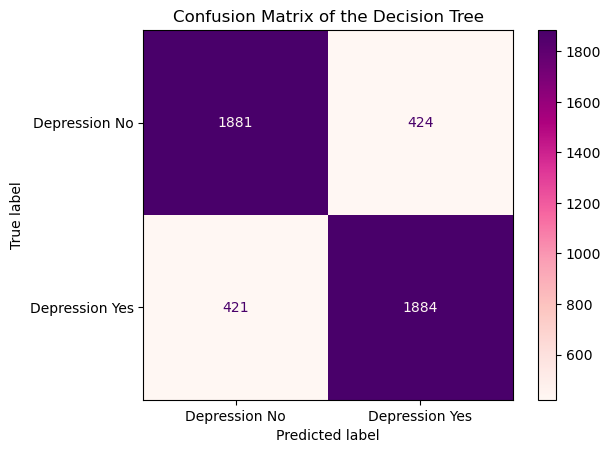

In [86]:
#Code for HeatMap
fig = ConfusionMatrixDisplay.from_estimator(
        tree_best,
        X_test,
        y_test,
        display_labels=["Depression No","Depression Yes"],
        cmap=plt.cm.RdPu,
        normalize= None,
    )
fig.ax_.set_title("Confusion Matrix of the Decision Tree")


plt.show()

### Evaluation of our Decision Tree Classifier

The Model took very long (5+ Minutes) to compute.

it reached a decent Accuracy of 81.67%, with Sensitivity = 81.74%, and Specificity = 81.61%.

The Confusion Matrix Heat Map shows that the Decision Tree Classifier missclassified instances with Depression==No and Depression==Yes at very similar rates, which is also reflected in the sensitivity and specificity being almost the same value.
Overall the heatmap is very balanced and the amount of False Positive or False Negative predictions is reasonably low compared to the correct predictions.

## Algorithm 2 : Random Forest

Since the Decision Tree Classifier took very long to compute (most likely because of the hyperparameter tuning using CV), we are going to try a Random Forest Classifier next. Since Random Forest already balances bias/variance by itself, we can skip using CV and just "guess" parameters based on recommendations from our lecture slides.

Important parameters:
- criterion / impurity metric -> lecture slides recommend gini or entropy. We used gini because it's the default setting
- n_estimators -> anything between 100 and 500 works. We used 100
- max_samples -> we used "None" to use sample size same as dataset size
- max_features -> rule of thumb: use sqrt(X_features)
- max_depth -> recommandation from lecture slides: use values between 1 and 7

Create Random Forest

In [106]:
#Code for implementing Random Forest

forest = RandomForestClassifier(n_estimators=500, # grows 100 trees
                                max_samples=None, # uses sample size same as dataset size
                                max_features='sqrt', # rule of thumb
                                max_depth=3, # between 1 and 7
                                random_state=0,                                
                                n_jobs=-1)
forest.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Calculate Accuracy

In [107]:
y_pred = forest.predict(X_test)
forest_accuracy = accuracy_score(y_test, y_pred)
print(f"Our Random Forest Classifier can predict whether someone has depression or not with an accuracy of {forest_accuracy*100:.2f}%")

Our Random Forest Classifier can predict whether someone has depression or not with an accuracy of 82.30%


Calculate Sensitivity and Specificity

In [108]:
cm = confusion_matrix(y_test, y_pred)
tn = cm[0, 0]
tp = cm[1, 1]
fn = cm[1, 0]
fp = cm[0, 1]

forest_sensitivity = tp / (tp + fn)
forest_specificity = tn / (tn + fp)

print(f"Our Forest Classifiers sensitivity is {forest_sensitivity*100:.2f}%, and specificity is {forest_specificity*100:.2f}%")

Our Forest Classifiers sensitivity is 83.56%, and specificity is 81.04%


Plot Confusion Matrix of Random Forest as a HeatMap

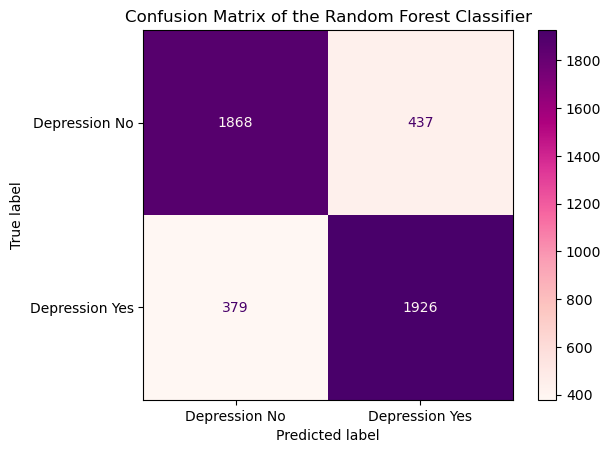

In [109]:
fig = ConfusionMatrixDisplay.from_estimator(
        forest,
        X_test,
        y_test,
        display_labels=["Depression No","Depression Yes"],
        cmap=plt.cm.RdPu,
        normalize= None,
    )
fig.ax_.set_title("Confusion Matrix of the Random Forest Classifier")


plt.show()

### Evaluation of our Random Forest Classifier

Compared to the Decision Tree Classifier:
- Advantage: Took way less time to compute than the Decision Tree (just 4 seconds vs 5 minutes for Decision Tree) and still reached about the same (even slightly higher) Accuracy of 82.30%. The Specificity (81.04%) was slightly lower than for the Decision Tree, but the Sensitivity (83.56%) got higher.
- Disadvantage: Random Forest is not an explainable algorithm -> you can't look at feature importances like you can with a single Decision Tree

The Confusion Matrix Heat Map shows that the Random Forest Classifier missclassified instances with Depression==No more often than instances with Depression==Yes, so there are more False Positive than False Negative ones. This is also reflected in the higher sensitivity compared to specificity. 

In a medical context, False Negative predictions are more dangerous then False Positives, as classifying a depressed individual as "not depressed" may prevent them from receiving the medical support they need. From this perspective, the lower number of False Negatives is a positive aspect of our Random Forest Classifier.

Overall the Heat Map is still pretty balanced, and the amount of False Positive or False Negative Predictions is reasonably low compared to the correct predictions.


## Algorithm 3 : KNN


Since k-NN is a simple and intuitive distance-based classification algorithm, we decided to implement it as our third model. k-NN does classifies new instances based on the labels of the nearest data points in the training set.

Because k-NN relies on distance calculations, it is important that all numerical features are on a similar scale. Therefore, we normalized the data before applying the algorithm. We chose the value k = 15 based on recommendations from the lecture slides and to avoid overfitting while still capturing local patterns in the data.

Important parameters:
- n_neighbors (k) -> number of nearest neighbors used for classification. We chose k = 15
- metric -> distance metric used to measure similarity. We used Euclidean distance
- weights -> determines how neighbors contribute to the prediction. We used uniform weights, meaning all neighbors have equal influence

Creates k-NN Classifier with k=15

In [91]:
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="uniform",   # all neighbors vote equally
    metric="euclidean"   # default distance for k-NN
)

Train the model

In [92]:
knn.fit(X_train, y_train)

,n_neighbors,15
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


Evaluate k-NN Model (Accuracy)

In [93]:
y_pred = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred)

print(f"Our k-NN Classifier (k=15) can predict whether someone has depression or not with an accuracy of {knn_accuracy*100:.2f}%.")

Our k-NN Classifier (k=15) can predict whether someone has depression or not with an accuracy of 81.78%.


Calculate Sensitivity and Specificity

In [94]:
cm = confusion_matrix(y_test, y_pred)
tn = cm[0, 0]
tp = cm[1, 1]
fn = cm[1, 0]
fp = cm[0, 1]

knn_sensitivity = tp / (tp + fn)
knn_specificity = tn / (tn + fp)

print(f"Our k-NN Classifiers (k=15) sensitivity is {knn_sensitivity*100:.2f}%, and specificity is {knn_specificity*100:.2f}%")

Our k-NN Classifiers (k=15) sensitivity is 82.47%, and specificity is 81.08%


Confusion Matrix (HeatMap)

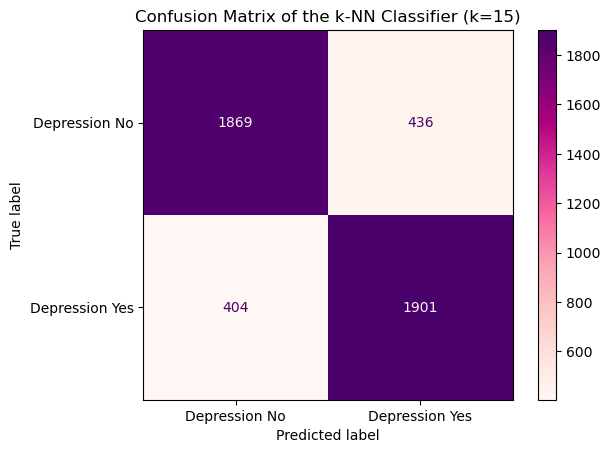

In [96]:
fig = ConfusionMatrixDisplay.from_estimator(
    knn,
    X_test,
    y_test,
    display_labels=["Depression No","Depression Yes"],
    cmap=plt.cm.RdPu,
    normalize=None
)

fig.ax_.set_title("Confusion Matrix of the k-NN Classifier (k=15)")
plt.show()

### Evaluation of our k-NN Classifier
Compared to the Decision Tree and Random Forest Classifiers:

- Advantage: After normalizing the data and choosing k = 15, the model achieved an accuracy of 81.78% (with sensitivity 82.47%, and specificity 81.08%), which is similar to the results of the Decision Tree and Random Forest classifiers.

- Disadvantage: k-NN is sensitive to feature scaling and noisy data, which is why proper normalization was required before applying the algorithm. In addition, k-NN is not an explainable model, as it does not provide feature importance information like a Decision Tree. The prediction step can also be slower, since distances to all training samples must be calculated.

The Confusion Matrix Heat Map shows that the k-NN classifier misclassified instances with Depression == No slightly more often than instances with Depression == Yes, similar to the other models. This is also reflected in higher sensitivity compared to specificity, and can again be considered a positive aspect in a medical context (where False Negative predictions are more critical than False Positive ones).

However, the overall results are fairly balanced, and the number of incorrect predictions is relatively small compared to the number of correct predictions.

## Algorithm 4 : Artificial Neural Networks (ANN)

In this section, we implemented an Artificial Neural Network using the MLPClassifier from scikit-learn, following the guidelines from the course slides.

- hidden_layer_sizes: Represents the number of neurons in the hidden layer. Default is 100
- solver (adam): We selected the 'adam' solver. While 'lbfgs' or 'sgd' are often better for small datasets, 'adam' is explicitly recommended for large datasets like ours.
- activation (logistic): We used the logistic activation function. It is important to note that when using logistic activation, input data should be scaled properly to the [0, 1] range. We made in data preparation.
- alpha: We set alpha=0.01, which is higher than the default and with that way we are stricly putting line against overfitting. (0.0001).

Creating the ANN model and testing.

In [97]:
mlp = MLPClassifier(hidden_layer_sizes=(10,),
                   activation='logistic',
                   solver='adam', # We used adam because our dataset is really big 
                   alpha=0.01, 
                   learning_rate='constant',
                   learning_rate_init=0.01, #Important for securing against overfitting
                   batch_size='auto',
                   max_iter=200, #Also important against overfitting.
                   random_state=1)

mlp.fit(X_train, y_train)

,hidden_layer_sizes,"(10,)"
,activation,'logistic'
,solver,'adam'
,alpha,0.01
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,1


Calculating Accuracy.

In [99]:
y_pred = mlp.predict(X_test)
ann_accuracy = accuracy_score(y_test, y_pred)
print(f"Our ANN Classifier can predict whether someone has depression or not with an accuracy of {ann_accuracy*100:.2f}%")

Our ANN Classifier can predict whether someone has depression or not with an accuracy of 83.80%


Calculate Sensitivity and Specificity

In [101]:
cm = confusion_matrix(y_test, y_pred)
tn = cm[0, 0]
tp = cm[1, 1]
fn = cm[1, 0]
fp = cm[0, 1]

ann_sensitivity = tp / (tp + fn)
ann_specificity = tn / (tn + fp)

print(f"Our ANN Classifiers sensitivity is {ann_sensitivity*100:.2f}%, and specificity is {ann_specificity*100:.2f}%")

Our ANN Classifiers sensitivity is 79.78%, and specificity is 87.81%


Confusion Matrix (HeatMap)

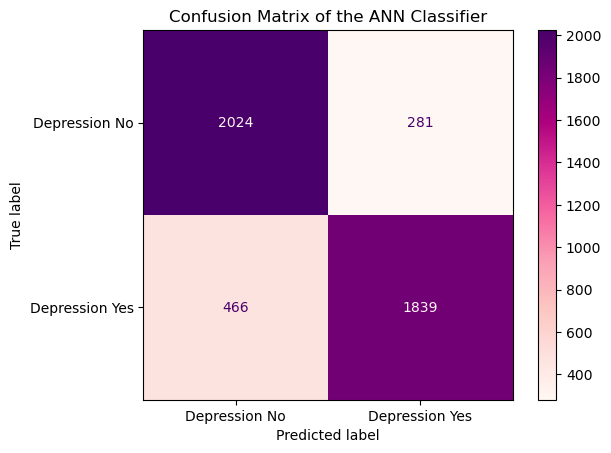

In [104]:
fig = ConfusionMatrixDisplay.from_estimator(
    mlp,
    X_test,
    y_test,
    display_labels=["Depression No", "Depression Yes"],
    cmap=plt.cm.RdPu,
    normalize=None
)

fig.ax_.set_title("Confusion Matrix of the ANN Classifier")
plt.show()

### Evaluation of our ANN Classifier

Compared to the other models:

Advantages: The ANN Classifier achieved the highest accuracy among all models with 83.80%, and a high specificity of 87.81%. The choice of the 'Adam' solver gave significant advantages to our model's performance, allowing it to learn efficiently from the dataset. 

Disadvantages: Neural Networks have many hyperparameters to tune (like neurons, layers, alpha). It can be time-consuming to find the best settings. Also, ANNs are generally prone to overfitting, so careful regularization was required. Furthermore, the models sensitivity is the lowest amongst all the classifiers we testet, with only 79.78%. This can be considered a negative aspect in a medical context, where False Negative predictions are more critical than False Positive ones.

The larger difference between sensitivity and specificity is also visible in the confusion matrix heat map, which is the most imbalanced one among the evaluated models.

## Conclusion



The following algorithms were implemented: Decision Trees, Random Forest, k Nearest Neighbors, and Artificial Neural Network. 
The Data preparation took a very long time for this data set, which is also evident from the fact that it takes up a lot of space in the notebook. The algorithms ran relatively quickly because they were very well aligned with our test tasks. In general, we were able to work a lot with things from our coursework or the material notebooks, which also helped us a lot. Overall, we found the project feasible. However, we would have liked to have had a sample notebook. We missed that a little. This would have been a good guide, especially for the interpretation (also in terms of quantity). 

In terms of model performance, the Artificial Neural Network achieved the highest overall accuracy. However, it also showed the lowest sensitivity (79.7%), meaning it was comparatively less effective at correctly identifying individuals who are actually depressed. Given the medical context of this project, this is a critical limitation, as false negatives could result in affected individuals not receiving the support or further evaluation they may need. The Random Forest model, which achieved the second-highest accuracy (82.3%), performed better in this respect, reaching a sensitivity of 83.5%, the highest among all tested models. As sensitivity is particularly important when the goal is to identify individuals at risk, the Random Forest model appears to be the most suitable choice overall for this application.

## Outlook of Depolyment 

As an outlook on potential deployment, the developed model could be integrated into a preliminary mental health screening tool. For example, individuals could complete a standardized questionnaire, and their responses could be processed by the model to classify whether they may be at risk of depression. Based on this classification, users identified as potentially at risk could receive a recommendation to seek further professional evaluation or medical advice.

It is crucial to emphasize that such a system cannot and must not replace a clinical diagnosis. The model does not provide a medical diagnosis and cannot function as a substitute for a qualified healthcare professional. Instead, it should be understood as a supportive tool that offers an initial indication and helps raise awareness, while any final diagnosis and treatment decisions must be made exclusively by medical professionals.


## Contribution of each Team Member

<b>Caner Dis:</b> Found a suitable dataset for the project and implemented the Artificial Neural Network algorithm.

<b>Rapolas Jonas Labutis:</b> Implemented the k-Nearest Neighbors (k-NN) algorithm, including parameter selection, model training, evaluation, and visualization using accuracy and a confusion matrix.

<b>Marwa Alnaser:</b> Co-developed the data preparation plan together with other team members. Implemented the second part of the data preparation (steps 7 to 12), including encoding of categorical variables, train-test split and normalization.

<b>Leila Schwindling:</b> Co-developed the data preparation plan together with other team members. Implemented the first part of the data preparation (steps 1 to 6), including initial data exploration, data cleaning and balancing classes. Wrote introduction, conclusion, outlook od deployment and interpretation of the Decision Tree feature importances.

<b>Sarah Bauer:</b> Co-developed the data preparation plan together with other team members. Implemented the algorithms Decision Tree and Random Forest, including basic hyperparameter selection, model training, evaluation and visualizations.

